In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

In [21]:
PATH = '/kaggle/input/datasets/martj42/international-football-results-from-1872-to-2017/'

results      = pd.read_csv(PATH + 'results.csv')
shootouts    = pd.read_csv(PATH + 'shootouts.csv')
goalscorers  = pd.read_csv(PATH + 'goalscorers.csv')
former_names = pd.read_csv(PATH + 'former_names.csv')

print("results     :", results.shape)
print("shootouts   :", shootouts.shape)
print("goalscorers :", goalscorers.shape)
print(results.head(3))

results     : (49287, 9)
shootouts   : (675, 5)
goalscorers : (47601, 8)
         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  


In [22]:
results['date'] = pd.to_datetime(results['date'])
df = results[results['date'] >= '2000-01-01'].copy()
df = df.sort_values('date').reset_index(drop=True)

def get_result(row):
    if pd.isna(row['home_score']) or pd.isna(row['away_score']):
        return np.nan
    if row['home_score'] > row['away_score']:
        return 1
    elif row['home_score'] < row['away_score']:
        return -1
    else:
        return 0

df['result']         = df.apply(get_result, axis=1)
df['home_advantage'] = (~df['neutral']).astype(int)

print("Shape :", df.shape)
print(df['result'].value_counts())

Shape : (25229, 11)
result
 1.0    12098
-1.0     7192
 0.0     5867
Name: count, dtype: int64


In [23]:
def get_team_form(team, date, df, n=10):
    past = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < date) &
        (df['result'].notna())
    ].tail(n)
    if len(past) == 0:
        return 0.5
    points = []
    for _, row in past.iterrows():
        if row['home_team'] == team:
            points.append(1 if row['result'] == 1 else (0.5 if row['result'] == 0 else 0))
        else:
            points.append(1 if row['result'] == -1 else (0.5 if row['result'] == 0 else 0))
    return np.mean(points)

def get_h2h(home_team, away_team, date, df, n=10):
    past = df[
        (((df['home_team'] == home_team) & (df['away_team'] == away_team)) |
         ((df['home_team'] == away_team) & (df['away_team'] == home_team))) &
        (df['date'] < date) &
        (df['result'].notna())
    ].tail(n)
    if len(past) == 0:
        return 0.5
    wins = 0
    for _, row in past.iterrows():
        if row['home_team'] == home_team:
            if row['result'] == 1: wins += 1
        else:
            if row['result'] == -1: wins += 1
    return wins / len(past)

def get_goals_avg(team, date, df, n=10):
    past = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < date) &
        (df['result'].notna())
    ].tail(n)
    if len(past) == 0:
        return 1.5
    goals = []
    for _, row in past.iterrows():
        if row['home_team'] == team:
            goals.append(row['home_score'])
        else:
            goals.append(row['away_score'])
    return np.mean(goals)

def get_goals_conceded(team, date, df, n=10):
    past = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < date) &
        (df['result'].notna())
    ].tail(n)
    if len(past) == 0:
        return 1.5
    goals = []
    for _, row in past.iterrows():
        if row['home_team'] == team:
            goals.append(row['away_score'])
        else:
            goals.append(row['home_score'])
    return np.mean(goals)

print("Fonctions définies !")

Fonctions définies !


In [24]:
print("Calcul en cours... patience !")

df['home_form']           = df.apply(lambda r: get_team_form(r['home_team'], r['date'], df), axis=1)
df['away_form']           = df.apply(lambda r: get_team_form(r['away_team'], r['date'], df), axis=1)
df['h2h']                 = df.apply(lambda r: get_h2h(r['home_team'], r['away_team'], r['date'], df), axis=1)
df['home_goals_avg']      = df.apply(lambda r: get_goals_avg(r['home_team'], r['date'], df), axis=1)
df['away_goals_avg']      = df.apply(lambda r: get_goals_avg(r['away_team'], r['date'], df), axis=1)
df['home_goals_conceded'] = df.apply(lambda r: get_goals_conceded(r['home_team'], r['date'], df), axis=1)
df['away_goals_conceded'] = df.apply(lambda r: get_goals_conceded(r['away_team'], r['date'], df), axis=1)

print("Done !")
print(df[['home_team','away_team','home_form','away_form','h2h']].tail(5))

Calcul en cours... patience !
Done !
      home_team  away_team  home_form  away_form  h2h
25224  Colombia   Portugal       0.65       0.75  0.5
25225    Panama    England       0.65       0.75  0.0
25226   Algeria    Austria       0.80       0.85  0.5
25227    Jordan  Argentina       0.60       0.85  0.5
25228   Croatia      Ghana       0.85       0.45  0.5


In [25]:
df['form_diff']    = df['home_form'] - df['away_form']
df['goals_diff']   = df['home_goals_avg'] - df['away_goals_avg']
df['conceded_diff']= df['home_goals_conceded'] - df['away_goals_conceded']
df['is_official']  = df['tournament'].apply(lambda x: 0 if x == 'Friendly' else 1)

le = LabelEncoder()
df['tournament_enc'] = le.fit_transform(df['tournament'])

features = [
    'home_form',
    'away_form',
    'h2h',
    'form_diff',
    'home_goals_avg',
    'away_goals_avg',
    'home_goals_conceded',
    'away_goals_conceded',
    'goals_diff',
    'conceded_diff',
    'home_advantage',
    'is_official',
    'tournament_enc'
]

print("Features prêtes :", features)

Features prêtes : ['home_form', 'away_form', 'h2h', 'form_diff', 'home_goals_avg', 'away_goals_avg', 'home_goals_conceded', 'away_goals_conceded', 'goals_diff', 'conceded_diff', 'home_advantage', 'is_official', 'tournament_enc']


In [26]:
df_model = df[features + ['result', 'date']].dropna()

X = df_model[features]
y = df_model['result']

X_train = X[df_model['date'] < '2023-01-01']
X_test  = X[df_model['date'] >= '2023-01-01']
y_train = y[df_model['date'] < '2023-01-01']
y_test  = y[df_model['date'] >= '2023-01-01']

y_train_enc = y_train.map({-1: 0, 0: 1, 1: 2})
y_test_enc  = y_test.map({-1: 0, 0: 1, 1: 2})

print(f"Train : {X_train.shape[0]} matchs")
print(f"Test  : {X_test.shape[0]} matchs")

Train : 21712 matchs
Test  : 3445 matchs


In [27]:
sample_weights = compute_sample_weight('balanced', y_train_enc)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train_enc, sample_weight=sample_weights)
print("Modèle entraîné !")

Modèle entraîné !


In [28]:
y_pred = model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test_enc, y_pred):.2%}")
print("\nRapport détaillé :")
print(classification_report(y_test_enc, y_pred,
      target_names=['Away win', 'Draw', 'Home win']))

Accuracy : 51.35%

Rapport détaillé :
              precision    recall  f1-score   support

    Away win       0.51      0.58      0.54      1036
        Draw       0.27      0.29      0.28       795
    Home win       0.67      0.58      0.62      1614

    accuracy                           0.51      3445
   macro avg       0.48      0.48      0.48      3445
weighted avg       0.53      0.51      0.52      3445



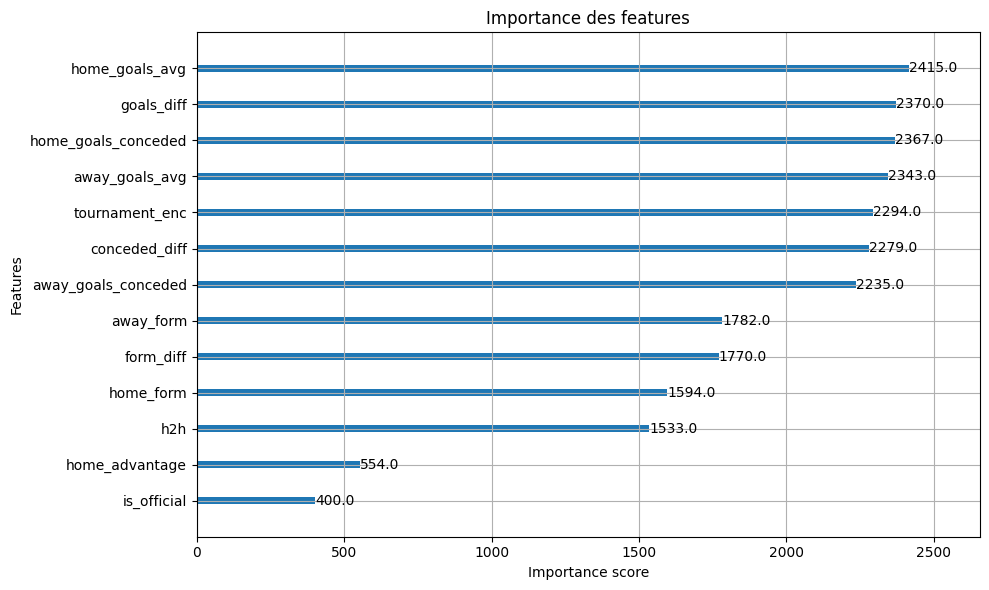

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(model, ax=ax, max_num_features=13)
plt.title('Importance des features')
plt.tight_layout()
plt.show()

In [30]:
cm2026 = df[
    (df['tournament'] == 'FIFA World Cup') &
    (df['date'].dt.year == 2026)
]

matchs_a_predire = cm2026[cm2026['home_score'].isna()].copy()
print(f"Matchs à prédire : {len(matchs_a_predire)}")

resultats = []

for _, row in matchs_a_predire.iterrows():
    home = row['home_team']
    away = row['away_team']
    date = row['date']

    home_f  = get_team_form(home, date, df)
    away_f  = get_team_form(away, date, df)
    h2h_val = get_h2h(home, away, date, df)
    hga     = get_goals_avg(home, date, df)
    aga     = get_goals_avg(away, date, df)
    hgc     = get_goals_conceded(home, date, df)
    agc     = get_goals_conceded(away, date, df)

    X_pred = pd.DataFrame([{
        'home_form'           : home_f,
        'away_form'           : away_f,
        'h2h'                 : h2h_val,
        'form_diff'           : home_f - away_f,
        'home_goals_avg'      : hga,
        'away_goals_avg'      : aga,
        'home_goals_conceded' : hgc,
        'away_goals_conceded' : agc,
        'goals_diff'          : hga - aga,
        'conceded_diff'       : hgc - agc,
        'home_advantage'      : 0,
        'is_official'         : 1,
        'tournament_enc'      : le.transform(['FIFA World Cup'])[0]
    }])

    proba = model.predict_proba(X_pred)[0]

    resultats.append({
        'date'      : date.strftime('%Y-%m-%d'),
        'home_team' : home,
        'away_team' : away,
        'proba_home': f"{proba[2]:.1%}",
        'proba_draw': f"{proba[1]:.1%}",
        'proba_away': f"{proba[0]:.1%}",
        'prediction': home if proba[2] > proba[0] and proba[2] > proba[1]
                      else (away if proba[0] > proba[1] else 'Draw')
    })

df_predictions = pd.DataFrame(resultats)
print(df_predictions.to_string(index=False))

Matchs à prédire : 72
      date              home_team              away_team proba_home proba_draw proba_away             prediction
2026-06-11                 Mexico           South Africa      20.6%      37.3%      42.1%           South Africa
2026-06-11            South Korea         Czech Republic      25.7%      32.3%      42.0%         Czech Republic
2026-06-12          United States               Paraguay      30.9%      32.8%      36.3%               Paraguay
2026-06-12                 Canada Bosnia and Herzegovina      28.0%      41.2%      30.7%                   Draw
2026-06-13                  Qatar            Switzerland      21.3%      27.0%      51.7%            Switzerland
2026-06-13                  Haiti               Scotland      22.4%      32.3%      45.3%               Scotland
2026-06-13              Australia                 Turkey      15.8%      36.9%      47.3%                 Turkey
2026-06-13                 Brazil                Morocco      16.3%      3

In [31]:
df_predictions.to_csv('/kaggle/working/predictions_cm2026.csv', index=False)
print("Fichier sauvegardé dans /kaggle/working/predictions_cm2026.csv")

Fichier sauvegardé dans /kaggle/working/predictions_cm2026.csv


In [32]:
groupes = {
    'A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'B': ['Canada', 'Qatar', 'Switzerland', 'Bosnia and Herzegovina'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Tunisia', 'Sweden'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Iraq', 'Senegal', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['DR Congo', 'Portugal', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

print("Groupes CM 2026 officiels :")
for groupe, equipes in groupes.items():
    print(f"  Groupe {groupe} : {equipes}")

Groupes CM 2026 officiels :
  Groupe A : ['Mexico', 'South Africa', 'South Korea', 'Czech Republic']
  Groupe B : ['Canada', 'Qatar', 'Switzerland', 'Bosnia and Herzegovina']
  Groupe C : ['Brazil', 'Morocco', 'Haiti', 'Scotland']
  Groupe D : ['United States', 'Paraguay', 'Australia', 'Turkey']
  Groupe E : ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador']
  Groupe F : ['Netherlands', 'Japan', 'Tunisia', 'Sweden']
  Groupe G : ['Belgium', 'Egypt', 'Iran', 'New Zealand']
  Groupe H : ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay']
  Groupe I : ['France', 'Iraq', 'Senegal', 'Norway']
  Groupe J : ['Argentina', 'Algeria', 'Austria', 'Jordan']
  Groupe K : ['DR Congo', 'Portugal', 'Uzbekistan', 'Colombia']
  Groupe L : ['England', 'Croatia', 'Ghana', 'Panama']


In [54]:
def simuler_groupe(groupe_nom, equipes, df_pred):
    points     = {eq: 0 for eq in equipes}
    diff_buts  = {eq: 0 for eq in equipes}

    from itertools import combinations
    matchs = list(combinations(equipes, 2))

    for home, away in matchs:
        match = df_pred[
            ((df_pred['home_team'] == home) & (df_pred['away_team'] == away)) |
            ((df_pred['home_team'] == away) & (df_pred['away_team'] == home))
        ]

        if len(match) == 0:
            date    = pd.Timestamp('2026-06-15')
            home_f  = get_team_form(home, date, df)
            away_f  = get_team_form(away, date, df)
            h2h_val = get_h2h(home, away, date, df)
            hga     = get_goals_avg(home, date, df)
            aga     = get_goals_avg(away, date, df)
            hgc     = get_goals_conceded(home, date, df)
            agc     = get_goals_conceded(away, date, df)

            X_pred = pd.DataFrame([{
                'home_form'           : home_f,
                'away_form'           : away_f,
                'h2h'                 : h2h_val,
                'form_diff'           : home_f - away_f,
                'home_goals_avg'      : hga,
                'away_goals_avg'      : aga,
                'home_goals_conceded' : hgc,
                'away_goals_conceded' : agc,
                'goals_diff'          : hga - aga,
                'conceded_diff'       : hgc - agc,
                'home_advantage'      : 0,
                'is_official'         : 1,
                'tournament_enc'      : le.transform(['FIFA World Cup'])[0]
            }])
            proba = model.predict_proba(X_pred)[0]
            prediction = home if proba[2] > proba[0] and proba[2] > proba[1] \
                         else (away if proba[0] > proba[1] else 'Draw')
        else:
            match      = match.iloc[0]
            prediction = match['prediction']
            home       = match['home_team']
            away       = match['away_team']

        if prediction == home:
            points[home]    += 3
            diff_buts[home] += 1
            diff_buts[away] -= 1
        elif prediction == away:
            points[away]    += 3
            diff_buts[home] -= 1
            diff_buts[away] += 1
        else:
            points[home] += 1
            points[away] += 1

    classement = sorted(equipes,
                        key=lambda x: (points[x], diff_buts[x]),
                        reverse=True)

    print(f"\nGroupe {groupe_nom} :")
    for i, eq in enumerate(classement):
        qualifie = "Q" if i < 2 else " "
        print(f"  {qualifie} {i+1}. {eq:30s} {points[eq]} pts  ({diff_buts[eq]:+d})")

    return classement[:2]

# Simuler tous les groupes
qualifies = {}
for groupe_nom, equipes in groupes.items():
    top2 = simuler_groupe(groupe_nom, equipes, df_predictions)
    qualifies[f'{groupe_nom}1'] = top2[0]
    qualifies[f'{groupe_nom}2'] = top2[1]

print("\n\nEquipes qualifiées :")
for cle, eq in qualifies.items():
    print(f"  {cle} : {eq}")


Groupe A :
  Q 1. Czech Republic                 7 pts  (+2)
  Q 2. South Korea                    6 pts  (+1)
    3. South Africa                   4 pts  (+0)
    4. Mexico                         0 pts  (-3)

Groupe B :
  Q 1. Canada                         5 pts  (+1)
  Q 2. Bosnia and Herzegovina         5 pts  (+1)
    3. Switzerland                    4 pts  (+0)
    4. Qatar                          1 pts  (-2)

Groupe C :
  Q 1. Morocco                        9 pts  (+3)
  Q 2. Brazil                         6 pts  (+1)
    3. Scotland                       3 pts  (-1)
    4. Haiti                          0 pts  (-3)

Groupe D :
  Q 1. Turkey                         7 pts  (+2)
  Q 2. Australia                      6 pts  (+1)
    3. Paraguay                       4 pts  (+0)
    4. United States                  0 pts  (-3)

Groupe E :
  Q 1. Ivory Coast                    7 pts  (+2)
  Q 2. Germany                        6 pts  (+1)
    3. Ecuador                        2 

In [57]:
# Ajouter les 8 meilleurs troisièmes dans qualifies
print("Classement des 3emes :")
for i, t in enumerate(troisiemes_sorted):
    cle = f'T{i+1}'
    qualifies[cle] = t['equipe']
    print(f"  {cle} : {t['equipe']:30s} {t['points']} pts ({t['diff_buts']:+d})")

print("\nVerification :")
for i in range(1, 9):
    print(f"  T{i} : {qualifies[f'T{i}']}")

Classement des 3emes :
  T1 : South Africa                   4 pts (+0)
  T2 : Switzerland                    4 pts (+0)
  T3 : Paraguay                       4 pts (+0)
  T4 : Algeria                        4 pts (+0)
  T5 : Scotland                       3 pts (-1)
  T6 : Tunisia                        3 pts (-1)
  T7 : Egypt                          3 pts (-1)
  T8 : Uruguay                        3 pts (-1)

Verification :
  T1 : South Africa
  T2 : Switzerland
  T3 : Paraguay
  T4 : Algeria
  T5 : Scotland
  T6 : Tunisia
  T7 : Egypt
  T8 : Uruguay


In [58]:
print("=" * 60)
print("         ROUND OF 32 — CM 2026")
print("=" * 60)

# Tableau officiel FIFA CM 2026
# 32 equipes = 12 premiers + 12 deuxiemes + 8 meilleurs 3emes
# 16 matchs au total
round32 = [
    (qualifies['A1'], qualifies['B2']),   # R1
    (qualifies['B1'], qualifies['A2']),   # R2
    (qualifies['C1'], qualifies['D2']),   # R3
    (qualifies['D1'], qualifies['C2']),   # R4
    (qualifies['E1'], qualifies['F2']),   # R5
    (qualifies['F1'], qualifies['E2']),   # R6
    (qualifies['G1'], qualifies['H2']),   # R7
    (qualifies['H1'], qualifies['G2']),   # R8
    (qualifies['I1'], qualifies['J2']),   # R9
    (qualifies['J1'], qualifies['I2']),   # R10
    (qualifies['K1'], qualifies['L2']),   # R11
    (qualifies['L1'], qualifies['K2']),   # R12
    (qualifies['T1'], qualifies['T2']),   # R13 — 3emes vs 3emes
    (qualifies['T3'], qualifies['T4']),   # R14
    (qualifies['T5'], qualifies['T6']),   # R15
    (qualifies['T7'], qualifies['T8']),   # R16
]

print(f"Nombre de matchs : {len(round32)}")

gagnants_r32 = []
for i, (home, away) in enumerate(round32):
    print(f"\n--- R{i+1} ---")
    gagnant = predict_match_ko(home, away)
    gagnants_r32.append(gagnant)

print(f"\n16 qualifies quarts : {gagnants_r32}")

         ROUND OF 32 — CM 2026
Nombre de matchs : 16

--- R1 ---
  Czech Republic            vs Bosnia and Herzegovina   
    Victoire Czech Republic       : 24.7%
    Match nul                      : 36.4%
    Victoire Bosnia and Herzegovina : 39.0%
    >>> Qualifie : Bosnia and Herzegovina


--- R2 ---
  Canada                    vs South Korea              
    Victoire Canada               : 22.4%
    Match nul                      : 49.4%
    Victoire South Korea          : 28.2%
    >>> Qualifie : South Korea


--- R3 ---
  Morocco                   vs Australia                
    Victoire Morocco              : 31.6%
    Match nul                      : 41.3%
    Victoire Australia            : 27.0%
    >>> Qualifie : Morocco


--- R4 ---
  Turkey                    vs Brazil                   
    Victoire Turkey               : 12.2%
    Match nul                      : 23.4%
    Victoire Brazil               : 64.3%
    >>> Qualifie : Brazil


--- R5 ---
  Ivory Coast      

In [61]:
# ============================================================
# QUARTS — 8 MATCHS (16 equipes → 8 qualifiés)
# ============================================================
print("\n" + "=" * 60)
print("          QUARTS DE FINALE CM 2026")
print("=" * 60)

quarts = [
    (gagnants_huitiemes[0],  gagnants_huitiemes[1]),   # QF1
    (gagnants_huitiemes[2],  gagnants_huitiemes[3]),   # QF2
    (gagnants_huitiemes[4],  gagnants_huitiemes[5]),   # QF3
    (gagnants_huitiemes[6],  gagnants_huitiemes[7]),   # QF4
    (gagnants_huitiemes[8],  gagnants_huitiemes[9]),   # QF5
    (gagnants_huitiemes[10], gagnants_huitiemes[11]),  # QF6
    (gagnants_huitiemes[12], gagnants_huitiemes[13]),  # QF7
    (gagnants_huitiemes[14], gagnants_huitiemes[15]),  # QF8
]

gagnants_quarts = []
for i, (home, away) in enumerate(quarts):
    print(f"--- QF{i+1} ---")
    gagnant = predict_match_ko(home, away)
    gagnants_quarts.append(gagnant)

print(f"\n8 qualifiés pour les demies : {gagnants_quarts}")


          QUARTS DE FINALE CM 2026
--- QF1 ---
  Bosnia and Herzegovina    vs Morocco                  
    Victoire Bosnia and Herzegovina : 20.0%
    Match nul                      : 29.4%
    Victoire Morocco              : 50.6%
    >>> Qualifie : Morocco

--- QF2 ---
  Japan                     vs Belgium                  
    Victoire Japan                : 19.1%
    Match nul                      : 34.8%
    Victoire Belgium              : 46.2%
    >>> Qualifie : Belgium

--- QF3 ---
  Austria                   vs England                  
    Victoire Austria              : 30.3%
    Match nul                      : 30.5%
    Victoire England              : 39.2%
    >>> Qualifie : England

--- QF4 ---
  South Korea               vs Brazil                   
    Victoire South Korea          : 14.8%
    Match nul                      : 30.8%
    Victoire Brazil               : 54.4%
    >>> Qualifie : Brazil

--- QF5 ---
  Germany                   vs Spain                   

In [62]:
# ============================================================
# DEMI-FINALES — 4 MATCHS (8 equipes → 4 qualifiés)
# ============================================================
print("\n" + "=" * 60)
print("           DEMI-FINALES CM 2026")
print("=" * 60)

demies = [
    (gagnants_quarts[0], gagnants_quarts[1]),   # DF1
    (gagnants_quarts[2], gagnants_quarts[3]),   # DF2
    (gagnants_quarts[4], gagnants_quarts[5]),   # DF3
    (gagnants_quarts[6], gagnants_quarts[7]),   # DF4
]

gagnants_demies  = []
perdants_demies  = []
for i, (home, away) in enumerate(demies):
    print(f"--- DF{i+1} ---")
    gagnant = predict_match_ko(home, away)
    perdant = away if gagnant == home else home
    gagnants_demies.append(gagnant)
    perdants_demies.append(perdant)

print(f"\nFinalistes : {gagnants_demies}")
print(f"Petite finale : {perdants_demies}")


           DEMI-FINALES CM 2026
--- DF1 ---
  Morocco                   vs Belgium                  
    Victoire Morocco              : 26.9%
    Match nul                      : 21.7%
    Victoire Belgium              : 51.5%
    >>> Qualifie : Belgium

--- DF2 ---
  England                   vs Brazil                   
    Victoire England              : 26.1%
    Match nul                      : 34.7%
    Victoire Brazil               : 39.2%
    >>> Qualifie : Brazil

--- DF3 ---
  Spain                     vs Croatia                  
    Victoire Spain                : 38.8%
    Match nul                      : 29.7%
    Victoire Croatia              : 31.6%
    >>> Qualifie : Spain

--- DF4 ---
  Switzerland               vs Uruguay                  
    Victoire Switzerland          : 29.9%
    Match nul                      : 32.1%
    Victoire Uruguay              : 38.0%
    >>> Qualifie : Uruguay


Finalistes : ['Belgium', 'Brazil', 'Spain', 'Uruguay']
Petite finale : ['

In [63]:
# ============================================================
# PETITE FINALE — 2 MATCHS → 1 match pour la 3ème place
# ============================================================
print("\n" + "=" * 60)
print("      PETITES FINALES CM 2026 — pour la 3eme place")
print("=" * 60)

# 4 perdants des demies jouent entre eux
print("--- PETITE FINALE 1 ---")
gagnant_pf1 = predict_match_ko(perdants_demies[0], perdants_demies[1])

print("--- PETITE FINALE 2 ---")
gagnant_pf2 = predict_match_ko(perdants_demies[2], perdants_demies[3])

# ============================================================
# MATCH 3EME PLACE
# ============================================================
print("\n" + "=" * 60)
print("      MATCH 3EME PLACE CM 2026")
print("=" * 60)

print("--- 3EME PLACE ---")
troisieme = predict_match_ko(gagnant_pf1, gagnant_pf2)

# ============================================================
# GRANDE FINALE
# ============================================================
print("\n" + "=" * 60)
print("         GRANDE FINALE CM 2026")
print("=" * 60)

print("--- FINALE ---")
champion = predict_match_ko(gagnants_demies[0], gagnants_demies[1])

print("\n" + "=" * 60)
print(f"  3EME PLACE             : {troisieme}")
print(f"  CHAMPION DU MONDE 2026 : {champion} !")
print("=" * 60)


      PETITES FINALES CM 2026 — pour la 3eme place
--- PETITE FINALE 1 ---
  Morocco                   vs England                  
    Victoire Morocco              : 23.1%
    Match nul                      : 35.7%
    Victoire England              : 41.2%
    >>> Qualifie : England

--- PETITE FINALE 2 ---
  Croatia                   vs Switzerland              
    Victoire Croatia              : 28.2%
    Match nul                      : 36.3%
    Victoire Switzerland          : 35.5%
    >>> Qualifie : Switzerland


      MATCH 3EME PLACE CM 2026
--- 3EME PLACE ---
  England                   vs Switzerland              
    Victoire England              : 33.4%
    Match nul                      : 41.1%
    Victoire Switzerland          : 25.6%
    >>> Qualifie : England


         GRANDE FINALE CM 2026
--- FINALE ---
  Belgium                   vs Brazil                   
    Victoire Belgium              : 44.2%
    Match nul                      : 22.5%
    Victoire Brazil 